# Network Construction and Feature Selection with BoBa-T

This tutorial demonstrates how to:
1. Build gene regulatory networks from scATAC-seq data
2. Perform LASSO-based feature selection to prune networks
3. Adaptively select regularization parameters for optimal network topology
4. Compare and visualize network properties



## Setup and Imports

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import bobaT as bb

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## Configure Paths

In [6]:
# Set your working directory
dir_prefix = '.'

# Input directories
DIRECT_NET_DIR = os.path.join(dir_prefix, 'test_data')
DATA_DIR = os.path.join(dir_prefix, 'test_data')

# Output directory
NETWORK_OUTDIR = os.path.join(dir_prefix, 'networks')
os.makedirs(NETWORK_OUTDIR, exist_ok=True)

print(f"Working directory: {dir_prefix}")
print(f"DIRECT-NET data: {DIRECT_NET_DIR}")
print(f"Output directory: {NETWORK_OUTDIR}")

Working directory: .
DIRECT-NET data: ./test_data
Output directory: ./networks


---
## Part 1: Load and Explore DIRECT-NET Data

DIRECT-NET provides TF-target predictions with motif scores. We'll explore the distribution of scores and set an initial threshold. BoBa-T works with any data file that has TFs, target nodes, and optimally some sort of score (like a motif score). 

In [7]:
# Load DIRECT-NET predictions
direct_net_file = os.path.join(DIRECT_NET_DIR, 'Direct_net_0.1.csv')
direct_net = pd.read_csv(direct_net_file, header=0, index_col=0)

# Standardize gene names to uppercase
direct_net['Target_gene'] = direct_net['Target_gene'].str.upper()

print(f"DIRECT-NET data loaded: {direct_net.shape[0]} TF-target interactions")
print(f"Columns: {list(direct_net.columns)}")
direct_net.head()

DIRECT-NET data loaded: 1298 TF-target interactions
Columns: ['regulatory regions', 'TF motif', 'motif score', 'Target_gene']


,regulatory regions,TF motif,motif score,Target_gene
1,chr5_136394557_136395437_Cux1,PPARG,9.432222,CUX1
2,chr6_72736650_72737562_Tcf7l1,PPARG,13.168407,TCF7L1
3,chr6_72740374_72741224_Tcf7l1,PPARG,9.306865,TCF7L1
4,chr9_63968292_63969164_Smad3,PPARG,9.969222,SMAD3
5,chr16_50594630_50595552_Bbx,PPARG,12.514526,BBX


### Visualize Motif Score Distribution

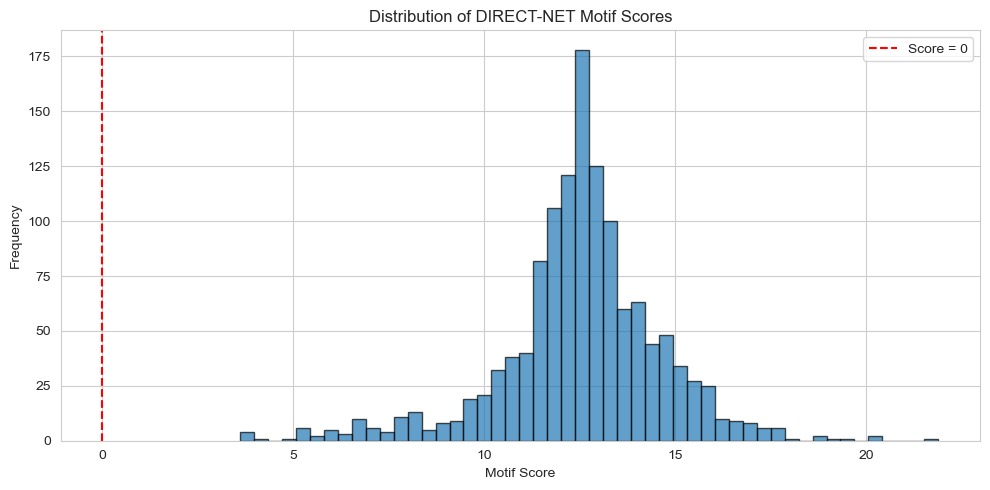


Motif score statistics:
count    1298.000000
mean       12.524504
std         2.138108
min         3.607144
25%        11.659460
50%        12.551152
75%        13.576800
max        21.885676
Name: motif score, dtype: float64


In [8]:
plt.figure(figsize=(10, 5))
plt.hist(direct_net['motif score'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Motif Score')
plt.ylabel('Frequency')
plt.title('Distribution of DIRECT-NET Motif Scores')
plt.axvline(0, color='red', linestyle='--', label='Score = 0')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nMotif score statistics:")
print(direct_net['motif score'].describe())

---
## Part 2: Build Initial Network

We'll construct a directed graph from the DIRECT-NET data, applying a threshold to filter weak interactions.

In [9]:
# Set threshold for motif score
# You can adjust this based on the distribution above
THRESHOLD = 0  # Change this value based on your data

print(f"Building network with motif score threshold: {THRESHOLD}")

# Build network
G = bb.net.build_network_from_directnet(
    direct_net, 
    threshold=THRESHOLD, 
    threshold_var='motif score'
)

print(f"\nNetwork statistics:")
print(f"  Nodes: {G.number_of_nodes()}")
print(f"  Edges: {G.number_of_edges()}")
print(f"  Average in-degree: {np.mean([d for n, d in G.in_degree()]):.2f}")
print(f"  Average out-degree: {np.mean([d for n, d in G.out_degree()]):.2f}")

Building network with motif score threshold: 0


AttributeError: module 'bobaT.make_tf_network' has no attribute 'build_network_from_directnet'

### Analyze Network Topology

In [ ]:
# Calculate degree distributions
in_degrees = [d for n, d in G.in_degree()]
out_degrees = [d for n, d in G.out_degree()]

# Plot degree distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-degree (number of regulators per gene)
axes[0].hist(in_degrees, bins=range(max(in_degrees) + 2), 
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Regulators (In-degree)')
axes[0].set_ylabel('Number of Genes')
axes[0].set_title('In-Degree Distribution')
axes[0].axvline(np.mean(in_degrees), color='red', 
                linestyle='--', label=f'Mean = {np.mean(in_degrees):.1f}')
axes[0].legend()

# Out-degree (number of targets per TF)
axes[1].hist(out_degrees, bins=range(max(out_degrees) + 2), 
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Targets (Out-degree)')
axes[1].set_ylabel('Number of TFs')
axes[1].set_title('Out-Degree Distribution')
axes[1].axvline(np.mean(out_degrees), color='red', 
                linestyle='--', label=f'Mean = {np.mean(out_degrees):.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Identify genes with many regulators
high_indegree = [(n, d) for n, d in G.in_degree() if d > 10]
if high_indegree:
    print(f"\nGenes with >10 regulators: {len(high_indegree)}")
    print("Top 5:")
    for gene, degree in sorted(high_indegree, key=lambda x: x[1], reverse=True)[:5]:
        print(f"  {gene}: {degree} regulators")

### Save Initial Network

In [ ]:
# Save network to CSV
network_name = "DIRECT-NET_network_2020db_0.1"
network_file = os.path.join(NETWORK_OUTDIR, f"{network_name}.csv")

bb.net.save_network(network_file, G, attributes=True, overwrite=True)

# Also save as DataFrame for easier manipulation
network_df = pd.DataFrame([
    {
        'source': edge[0],
        'target': edge[1],
        'weight': G[edge[0]][edge[1]].get('weight', np.nan),
        'evidence': G[edge[0]][edge[1]].get('evidence', '')
    }
    for edge in G.edges()
])

print(f"\nNetwork saved as DataFrame:")
print(network_df.head())

---
## Part 3: Load Expression Data

We need expression data to perform LASSO regression. Each column should be a gene, each row an observation (cell, sample, etc.).

In [ ]:
# Load expression data
# Adjust the filename as needed
data_path = os.path.join(DATA_DIR, './test_data/data.csv')

# Check if file exists
if os.path.exists(data_path):
    data = pd.read_csv(data_path, index_col=0, header=0)
    
    # Standardize gene names to uppercase
    data.columns = [col.upper() for col in data.columns]
    
    print(f"Expression data loaded: {data.shape[0]} observations, {data.shape[1]} genes")
    print(f"\nFirst few genes: {list(data.columns[:5])}")
    
    # Verify overlap with network
    network_genes = set(network_df['source']).union(set(network_df['target']))
    data_genes = set(data.columns)
    overlap = network_genes.intersection(data_genes)
    
    print(f"\nGene overlap:")
    print(f"  Network genes: {len(network_genes)}")
    print(f"  Data genes: {len(data_genes)}")
    print(f"  Overlap: {len(overlap)} ({len(overlap)/len(network_genes)*100:.1f}%)")
    
    if len(overlap) < len(network_genes) * 0.5:
        print("\nWARNING: Less than 50% gene overlap! Check gene naming conventions.")
else:
    print(f"ERROR: Expression data file not found at {data_path}")
    print("Please update the data_path variable with the correct file location.")
    data = None

---
## Part 4: LASSO Feature Selection

Now we'll use LASSO regression to identify the most important regulators for each target gene. LASSO will:
1. Perform L1 regularization to drive weak coefficients to zero
2. Select only the most predictive TFs for each target
3. Test multiple alpha values to control regularization strength

**Note**: This step can take several minutes depending on network size.

In [ ]:
# Only run if expression data is loaded
if data is not None:
    # Define alpha values to test
    # Smaller alpha = less regularization = more features retained
    # Larger alpha = more regularization = fewer features retained
    alphas = [0.00001, 0.0001, 0.001, 0.01, 0.1, 1]
    
    print(f"Running LASSO feature selection with alphas: {alphas}")
    print("This may take several minutes...\n")
    
    # Run LASSO feature selection
    alpha_scores = bb.net.lasso_feature_selection(
        network=network_df,
        data=data,
        network_name=network_name,
        output_dir=NETWORK_OUTDIR,
        alphas=alphas,
        save_network=True,
        plot=True
    )
    
    print("\nLASSO feature selection complete!")
    print(f"Results saved to: {NETWORK_OUTDIR}/feature_selection/{network_name}/")
else:
    print("Skipping LASSO: expression data not loaded")

### Visualize LASSO Performance Across Alpha Values

In [ ]:
if data is not None and alpha_scores:
    # Calculate mean scores for each alpha
    mean_scores = {alpha: np.mean(scores) for alpha, scores in alpha_scores.items()}
    
    plt.figure(figsize=(10, 5))
    plt.plot(list(mean_scores.keys()), list(mean_scores.values()), 
             marker='o', linewidth=2, markersize=8)
    plt.xscale('log')
    plt.xlabel('Alpha (regularization strength)', fontsize=12)
    plt.ylabel('Mean R² Score', fontsize=12)
    plt.title('LASSO Performance vs Regularization Strength', fontsize=14)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nMean R² scores by alpha:")
    for alpha, score in sorted(mean_scores.items()):
        print(f"  α = {alpha:7.5f}: R² = {score:.4f}")

---
## Part 5: Compare Networks Across Alpha Values

Let's compare how different alpha values affect network topology.

In [ ]:
if data is not None:
    comparison_results = []
    
    for alpha in alphas:
        # Load filtered network
        filtered_net_path = os.path.join(
            NETWORK_OUTDIR, 
            'feature_selection',
            network_name,
            f'Lasso_alpha_{alpha}',
            f'{network_name}_Lasso_{alpha}.csv'
        )
        
        if os.path.exists(filtered_net_path):
            filtered_net = pd.read_csv(filtered_net_path)
            
            # Compare networks
            results = bb.net.compare_networks(
                original_network=network_df,
                filtered_network=filtered_net,
                alpha=alpha,
                save=True,
                save_dir=os.path.join(
                    NETWORK_OUTDIR, 
                    'feature_selection',
                    network_name
                )
            )
            
            comparison_results.append(results)
        else:
            print(f"Warning: Filtered network not found for alpha={alpha}")
    
    # Summarize results
    if comparison_results:
        print("\n" + "="*70)
        print("SUMMARY: Network Pruning Across Alpha Values")
        print("="*70)
        
        summary_df = pd.DataFrame([
            {
                'Alpha': r['alpha'],
                'Edges Dropped': r['n_dropped'],
                'Max Parents': r['max_parents'],
                'Target (max parents)': r['max_parents_target']
            }
            for r in comparison_results
        ])
        
        print(summary_df.to_string(index=False))
else:
    print("Skipping comparison: expression data not loaded")

---
## Part 6: Adaptive LASSO Pruning

Instead of using a single alpha for all targets, we can adaptively select the alpha that reduces each target's regulators to a desired maximum (e.g., 8 regulators).

In [ ]:
if data is not None:
    # Set maximum number of regulators per target
    MAX_PARENTS = 8
    
    print(f"Running adaptive LASSO pruning (max {MAX_PARENTS} parents per target)...\n")
    
    # Perform adaptive pruning
    pruned_network, tf_alpha_dict = bb.net.adaptive_lasso_pruning(
        network=network_df,
        output_dir=NETWORK_OUTDIR,
        network_name=network_name,
        max_parents=MAX_PARENTS,
        alphas=alphas
    )
    
    print(f"\nAdaptive pruning complete!")
    print(f"Original network: {len(network_df)} edges")
    print(f"Pruned network: {len(pruned_network)} edges")
    print(f"Reduction: {(1 - len(pruned_network)/len(network_df))*100:.1f}%")
    
    # Show distribution of selected alphas
    alpha_counts = pd.Series(list(tf_alpha_dict.values())).value_counts().sort_index()
    print(f"\nAlpha distribution across targets:")
    print(alpha_counts)
    
    # Save pruned network
    pruned_network_file = os.path.join(
        NETWORK_OUTDIR, 
        'feature_selection',
        network_name,
        f'combined_{network_name}_Lasso_adaptive_max{MAX_PARENTS}.csv'
    )
    pruned_network.to_csv(pruned_network_file, index=False, header=False)
    print(f"\nPruned network saved to: {pruned_network_file}")
else:
    print("Skipping adaptive pruning: expression data not loaded")

### Visualize Alpha Selection

In [ ]:
if data is not None and 'tf_alpha_dict' in locals():
    # Plot alpha distribution
    alpha_values = [v for v in tf_alpha_dict.values() if v != 'NA' and v != 0]
    
    if alpha_values:
        plt.figure(figsize=(10, 5))
        plt.hist(alpha_values, bins=len(set(alpha_values)), 
                 edgecolor='black', alpha=0.7)
        plt.xlabel('Selected Alpha Value', fontsize=12)
        plt.ylabel('Number of Targets', fontsize=12)
        plt.title('Distribution of Selected Alpha Values (Adaptive Pruning)', 
                  fontsize=14)
        plt.xscale('log')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Show some example targets
        print("\nExample targets and their selected alphas:")
        for i, (target, alpha) in enumerate(list(tf_alpha_dict.items())[:10]):
            n_parents = len(pruned_network[pruned_network['target'] == target])
            print(f"  {target}: α = {alpha}, {n_parents} regulators")

---
## Part 7: Visualize Network Changes

Let's visualize a subnetwork to see the effects of pruning.

In [ ]:
if data is not None and 'pruned_network' in locals():
    # Pick an interesting target gene (one that had many regulators)
    target_of_interest = comparison_results[0]['max_parents_target'] if comparison_results else None
    
    if target_of_interest:
        # Get original and pruned edges
        original_edges = network_df[network_df['target'] == target_of_interest]
        pruned_edges = pruned_network[pruned_network['target'] == target_of_interest]
        
        print(f"Example: {target_of_interest}")
        print(f"  Original regulators: {len(original_edges)}")
        print(f"  Pruned regulators: {len(pruned_edges)}")
        print(f"  Kept: {list(pruned_edges['source'].values)}")
        
        # Create subgraphs
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Original network
        G_orig = nx.DiGraph()
        G_orig.add_node(target_of_interest)
        for _, row in original_edges.iterrows():
            G_orig.add_edge(row['source'], row['target'])
        
        pos_orig = nx.spring_layout(G_orig, k=0.5, seed=42)
        nx.draw_networkx(
            G_orig, pos_orig, ax=axes[0],
            node_color=['#ff7f0e' if n == target_of_interest else '#1f77b4' 
                       for n in G_orig.nodes()],
            node_size=1000,
            font_size=8,
            arrows=True,
            arrowsize=10,
            edge_color='gray',
            alpha=0.7
        )
        axes[0].set_title(f'Original Network: {target_of_interest}\n'
                         f'{len(original_edges)} regulators', 
                         fontsize=12)
        axes[0].axis('off')
        
        # Pruned network
        G_pruned = nx.DiGraph()
        G_pruned.add_node(target_of_interest)
        for _, row in pruned_edges.iterrows():
            G_pruned.add_edge(row['source'], row['target'])
        
        pos_pruned = nx.spring_layout(G_pruned, k=0.5, seed=42)
        nx.draw_networkx(
            G_pruned, pos_pruned, ax=axes[1],
            node_color=['#ff7f0e' if n == target_of_interest else '#2ca02c' 
                       for n in G_pruned.nodes()],
            node_size=1000,
            font_size=8,
            arrows=True,
            arrowsize=10,
            edge_color='gray',
            alpha=0.7
        )
        axes[1].set_title(f'Pruned Network: {target_of_interest}\n'
                         f'{len(pruned_edges)} regulators (LASSO)', 
                         fontsize=12)
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()

---
## Bonus: Export for Boolean Modeling

The pruned network can now be used as input for network inference.

In [ ]:
if data is not None and 'pruned_network' in locals():
    # Create a NetworkX graph from pruned network
    G_pruned_final = nx.DiGraph()
    for _, row in pruned_network.iterrows():
        G_pruned_final.add_edge(row['source'], row['target'])
    
    print("Pruned network summary for Boolean modeling:")
    print(f"  Nodes: {G_pruned_final.number_of_nodes()}")
    print(f"  Edges: {G_pruned_final.number_of_edges()}")
    print(f"  Avg in-degree: {np.mean([d for n, d in G_pruned_final.in_degree()]):.2f}")
    print(f"  Max in-degree: {max([d for n, d in G_pruned_final.in_degree()])}")
    
    # Identify source nodes (potential initial conditions)
    source_nodes = [n for n, d in G_pruned_final.in_degree() if d == 0]
    print(f"\nSource nodes (no regulators): {len(source_nodes)}")
    if source_nodes:
        print(f"  Examples: {source_nodes[:5]}")
    
    # Ready for BooleaBayes!
    print("\n✅ Network is ready for Boolean modeling with BoBa-T!")